# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [4]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [191]:
?apply_deseq2_normalization

Signature:
apply_deseq2_normalization(
    counts_df,
    metadata_df,
    sample_col='sample',
    cond_col='condition',
    lowExprGenesQ=0.3,
    pseudocount=1,
)
Docstring:
Performs DESeq2-style median-of-ratios normalization.

Parameters
----------
counts_df : pd.DataFrame
    Raw count matrix (genes x samples). May contain additional annotation columns.
metadata_df : pd.DataFrame
    Metadata mapping samples to biological conditions.
sample_col : str, optional
    Column name in metadata_df containing sample IDs. Default is 'sample'.
cond_col : str, optional
    Column name in metadata_df containing condition labels. Default is 'condition'.
lowExprGenesQ : float, optional
    Quantile specifying the threshold to discard low-expressed genes 
    for size factor calculation. Default is 0.3.
pseudocount : float, optional
    Added count before dividing by size factor value. Essential if further 
    log transformation is performed. Default is 1.

Returns
-------
norm_counts_df : pd.

## Create sample count data

In [5]:
from zavolab_pyutils.read_count_simulation import simulate_negative_binomial_counts, simulate_poisson_lognormal_counts

In [81]:
# we generate the data under assumption of NO differentially expressed genes, so any significant changes between conditions are false positives!

In [175]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_10repl_df, metadata_10repl_df, nb_true_10repl_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=10, 
    alpha=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)

print("Negative Binomial Counts:")
print(nb_counts_df.head(2))

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  Sample_7  \
Gene_1     10991     12729     10981      6152     12525      9413      6650   
Gene_2      1218       744      1516       481       982       648       710   

        Sample_8  Sample_9  Sample_10  Sample_11  Sample_12  Sample_13  \
Gene_1      4704      6397       4741      13100       8189       7404   
Gene_2       649       948        345       1106       1004        788   

        Sample_14  Sample_15  Sample_16  Sample_17  Sample_18  Sample_19  \
Gene_1       5230       6095       8800       4772       9478       4632   
Gene_2        584        578        954        507       1543        625   

        Sample_20  
Gene_1       5701  
Gene_2        996  


In [176]:
nb_true_10repl_sf

array([1.64941468, 1.3201674 , 1.37355055, 0.75873576, 1.47686934,
       1.10445821, 0.85816963, 0.76267013, 0.96174599, 0.51096149,
       1.33903535, 0.99277081, 0.86460863, 0.7169284 , 0.84561388,
       1.36713317, 0.59829053, 1.04168122, 0.86993812, 1.0154115 ])

In [177]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_3repl_df, metadata_3repl_df, nb_true_3repl_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    alpha=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)

print("Negative Binomial Counts:")
print(nb_counts_df.head(2))

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  Sample_7  \
Gene_1     10991     12729     10981      6152     12525      9413      6650   
Gene_2      1218       744      1516       481       982       648       710   

        Sample_8  Sample_9  Sample_10  Sample_11  Sample_12  Sample_13  \
Gene_1      4704      6397       4741      13100       8189       7404   
Gene_2       649       948        345       1106       1004        788   

        Sample_14  Sample_15  Sample_16  Sample_17  Sample_18  Sample_19  \
Gene_1       5230       6095       8800       4772       9478       4632   
Gene_2        584        578        954        507       1543        625   

        Sample_20  
Gene_1       5701  
Gene_2        996  


In [178]:
nb_true_3repl_sf

array([1.64941468, 1.3201674 , 1.37355055, 0.75873576, 1.47686934,
       1.10445821])

In [179]:
# Generate Sanity-style data (Poisson-LogNormal)
pln_counts_3repl_df, metadata_3repl_df, pln_true_3repl_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    v_log=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)

pln_counts_10repl_df, metadata_10repl_df, pln_true_10repl_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=10, 
    v_log=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)
print("\nPoisson-LogNormal Counts:")
print(pln_counts_3repl_df.head(2))

print(pln_counts_10repl_df.head(2))


Poisson-LogNormal Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1     11362     13119     13872      6525     17332      4446
Gene_2      1327       813      1236       542      1025      1161
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  Sample_7  \
Gene_1     11362     13119     13872      6525     17332      4446      6399   
Gene_2      2165       898      1079       727       922       708      1173   

        Sample_8  Sample_9  Sample_10  Sample_11  Sample_12  Sample_13  \
Gene_1      4380      7831       3336       8887       9498       6466   
Gene_2       507       717        434       1609        668        813   

        Sample_14  Sample_15  Sample_16  Sample_17  Sample_18  Sample_19  \
Gene_1       5767       6918      14149       4315       8466       6402   
Gene_2        670        724       1181        674        987        625   

        Sample_20  
Gene_1       6653  
Gene_2       1055  


In [117]:
pln_true_3repl_sf

array([1.64941468, 1.3201674 , 1.37355055, 0.75873576, 1.47686934,
       1.10445821])

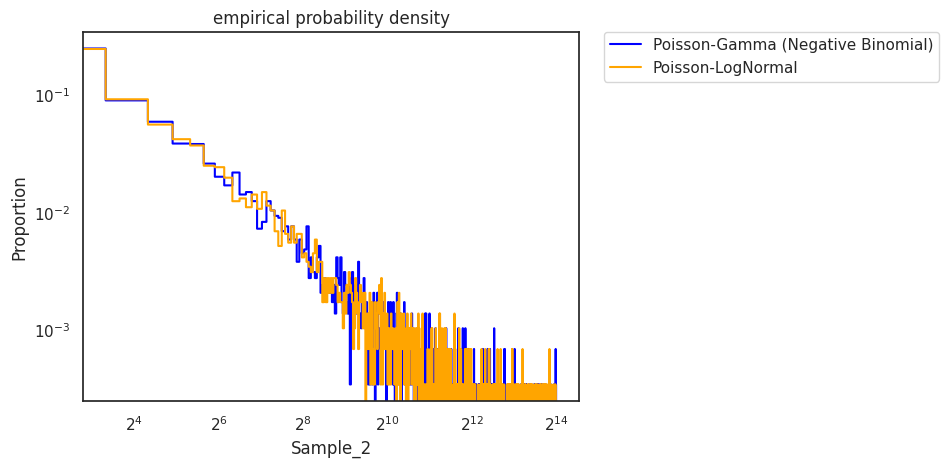

In [180]:
ax = sns.histplot(nb_counts_3repl_df['Sample_2']+1,stat="proportion",bins=range(0,2**14,10),color='blue',label='Poisson-Gamma (Negative Binomial)',element="step", fill=False)
ax = sns.histplot(pln_counts_3repl_df['Sample_2']+1,stat="proportion",bins=range(0,2**14,10),color='orange',label='Poisson-LogNormal',element="step", fill=False)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=10)
ax.set(title='empirical probability density')
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.0,
    title='',
    markerscale=1,
    ncol=1,
)

## DESeq2-style normalization and quantification

In [68]:
from zavolab_pyutils.read_count_data_analysis import apply_deseq2_normalization, model_mean_variance

In [72]:
# Apply normalization
norm_counts_3repl_df, sfs_3repl_df = apply_deseq2_normalization(
    nb_counts_3repl_df, 
    metadata_3repl_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

norm_counts_10repl_df, sfs_10repl_df = apply_deseq2_normalization(
    nb_counts_10repl_df, 
    metadata_10repl_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts_3repl_df.head(2))
print(f"\nShape: {norm_counts_3repl_df.shape}")

Normalized count matrix:
           Sample_1      Sample_2     Sample_3     Sample_4      Sample_5  \
Gene_1  8178.106000  11875.592759  9836.477056  9886.542347  10441.867457   
Gene_2  1005.895134    799.480204   898.377935  1219.549105   1297.105681   

            Sample_6  
Gene_1  10590.287879  
Gene_2   1101.326942  

Shape: (3000, 6)


In [76]:
print("Size factors and read metrics:")
print(sfs_3repl_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf  read_sum  read_sum_mln
sample                                              
Sample_1  1.344076  0.426615  24275349         24.28
Sample_2  1.071946  0.100233  17251615         17.25
Sample_3  1.116457  0.158927  20383148         20.38
Sample_4  0.622361 -0.684176   9918839          9.92
Sample_5  1.199594  0.262546  18959106         18.96
Sample_6  0.888928 -0.169862  14721419         14.72


### Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [80]:
print('for 3 bioreplicates per condition:')
print(f"Median size factor: {sfs_10repl_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_10repl_df['sf'].mean():.3f}")
print('\nfor 10 bioreplicates per condition:')
print(f"Median size factor: {sfs_3repl_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_3repl_df['sf'].mean():.3f}")

for 3 bioreplicates per condition:
Median size factor: 1.012
Mean size factor: 1.059

for 10 bioreplicates per condition:
Median size factor: 1.094
Mean size factor: 1.041


in case of small variability in library sizes the correlation may be not high!

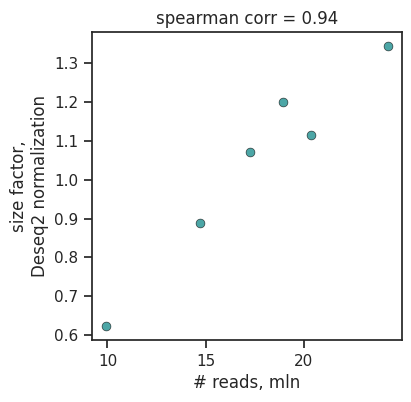

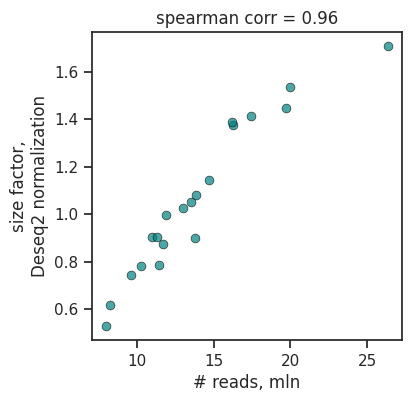

In [81]:
from zavolab_pyutils.visualization import plot_size_factors
plot_size_factors(sfs_3repl_df,savefig_path='./tests/plots/library_size_vs_SF.3repl.png')
plot_size_factors(sfs_10repl_df,savefig_path='./tests/plots/library_size_vs_SF.10repl.png')

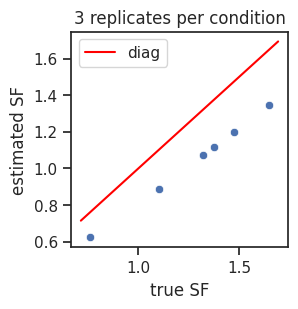

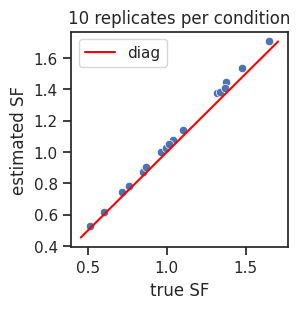

In [84]:
true_sfs = [nb_true_3repl_sf,nb_true_10repl_sf]
titles = ['3 replicates per condition','10 replicates per condition']
for k,data in enumerate([sfs_3repl_df,sfs_10repl_df]):
    data['true_sf'] = true_sfs[k]
    sns.set(font_scale=1, style="white")
    fig, axes = plt.subplots(1, 1, figsize=(2.8, 2.8))
    ax = sns.scatterplot(data = data,x='true_sf',y='sf')
    ax = sns.lineplot(data = pd.DataFrame([[ax.get_xlim()[0],ax.get_xlim()[0]],[ax.get_xlim()[1],ax.get_xlim()[1]]],columns=['true_sf','sf']),x='true_sf',y='sf',color='red',label='diag')
    ax.set(xlabel='true SF',ylabel='estimated SF',title=titles[k])
    ax.tick_params(left=True, bottom=True)

### Mean-Variance Modeling and Confidence Intervals

In [85]:
# Model the condition-specific dispersion using Quantile Regression
regr_model_3repl_df, all_plot_data_3repl_df = model_mean_variance(
    norm_counts_3repl_df, 
    metadata_3repl_df, 
    sample_col='sample', 
    cond_col='condition'
)

regr_model_10repl_df, all_plot_data_10repl_df = model_mean_variance(
    norm_counts_10repl_df, 
    metadata_10repl_df, 
    sample_col='sample', 
    cond_col='condition'
)

print("\nRegression Model Parameters (Alpha/Dispersion) for 3 replicates/condition:")
print(regr_model_3repl_df)
print("\nRegression Model Parameters (Alpha/Dispersion) for 10 replicates/condition:")
print(regr_model_10repl_df)


Regression Model Parameters (Alpha/Dispersion) for 3 replicates/condition:
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.034219
1  Treatment   QuantReg          var  0.034730

Regression Model Parameters (Alpha/Dispersion) for 10 replicates/condition:
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.046844
1  Treatment   QuantReg          var  0.046419


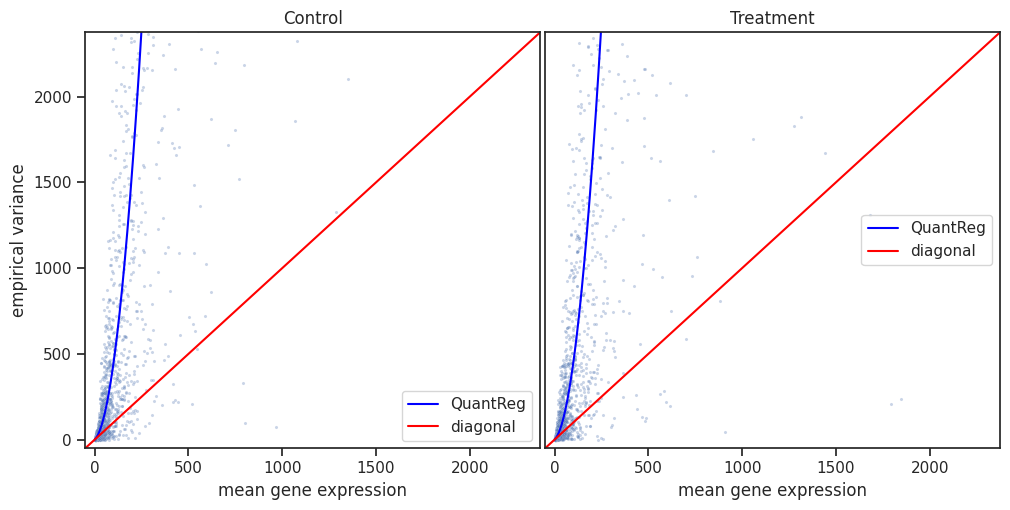

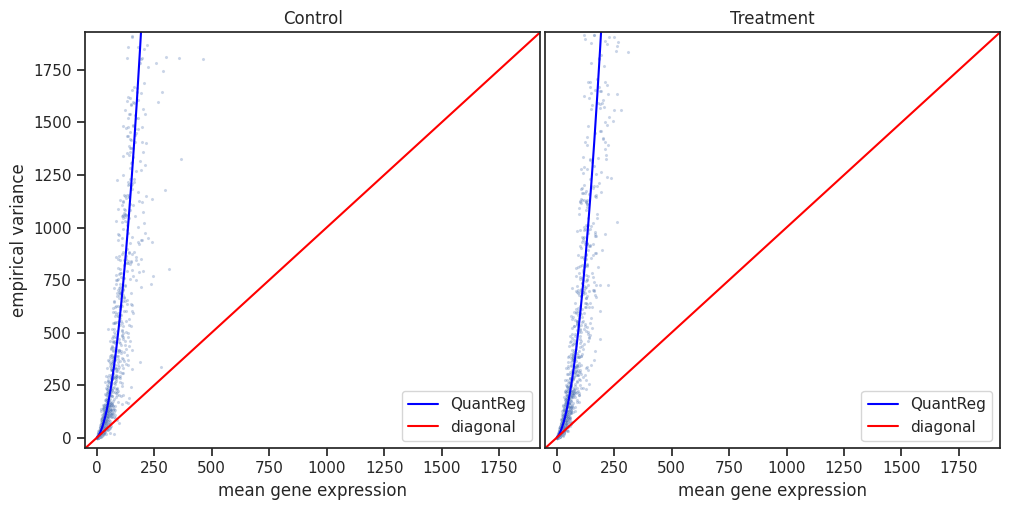

In [86]:
# Plot the diagnostic regression fits for variance within each condition
from zavolab_pyutils.visualization import plot_mean_variance_diagnostics
plot_mean_variance_diagnostics(
    all_plot_data_3repl_df, 
    savefig_path='./tests/plots/mean_variance_diagnostics.3repl.png'
)
plot_mean_variance_diagnostics(
    all_plot_data_10repl_df, 
    savefig_path='./tests/plots/mean_variance_diagnostics.10repl.png'
)

## Sanity style normalization and quantification

### First, we try to run original Sanity on simulated bulk data

we first run original Sanity from its [github repo](https://github.com/jmbreda/Sanity)

On Scicore HPC cluster, first load the necessary OpenMP module, (may be select the newest option available):
```bash
ml OpenMPI/5.0.8-GCC-14.3.0
```

In [181]:
from pathlib import Path

cmds = []
titles = ['3repl','10repl']
for k,data in enumerate([pln_counts_3repl_df,pln_counts_10repl_df]):
    cmd = "Sanity"
    sanity_format_df = data.copy()
    count_cols = list(sanity_format_df.columns)
    sanity_format_df['GeneID'] = sanity_format_df.index

    out_file_path = './tests/tables/Sanity_input_counts.'+titles[k]+'.tsv'
    dir_path = Path(out_file_path).parent
    dir_path.mkdir(parents=True, exist_ok=True)
    sanity_format_df[['GeneID']+count_cols].to_csv(out_file_path,sep=str('\t'),header=True,index=None)

    sanity_out_dir = './tests/tables/sanity_out_'+titles[k]+'/'
    dir_path = Path(sanity_out_dir)
    dir_path.mkdir(parents=True, exist_ok=True)
    cmd = cmd+" -f "+out_file_path+" -d "+sanity_out_dir+" -e true -vmin 0.0000001 -vmax 100"
    cmds.append(cmd)
print('\n'.join(cmds))

Sanity -f ./tests/tables/Sanity_input_counts.3repl.tsv -d ./tests/tables/sanity_out_3repl/ -e true -vmin 0.0000001 -vmax 100
Sanity -f ./tests/tables/Sanity_input_counts.10repl.tsv -d ./tests/tables/sanity_out_10repl/ -e true -vmin 0.0000001 -vmax 100


input counts for genes with unexpectedly high biological var, 3repl:

         Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
GeneID                                                             
Gene_17         0         0         0         0         0         1
Gene_27         2         0         0         0         0         0
Gene_37         0         0         0         0         1         0
fraction of genes with log10 CV < -2 is 0.156, 3repl, "Control" condition
fraction of genes with log10 CV < -2 is 0.129, 10repl, "Control" condition


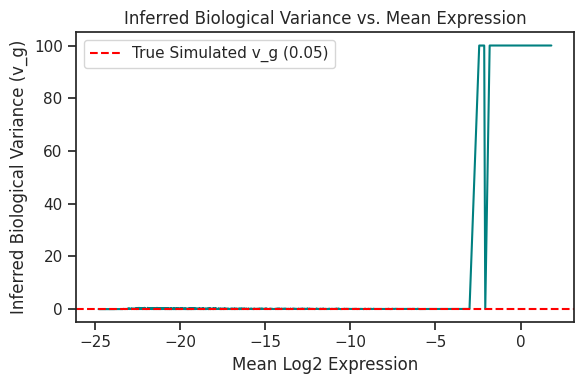

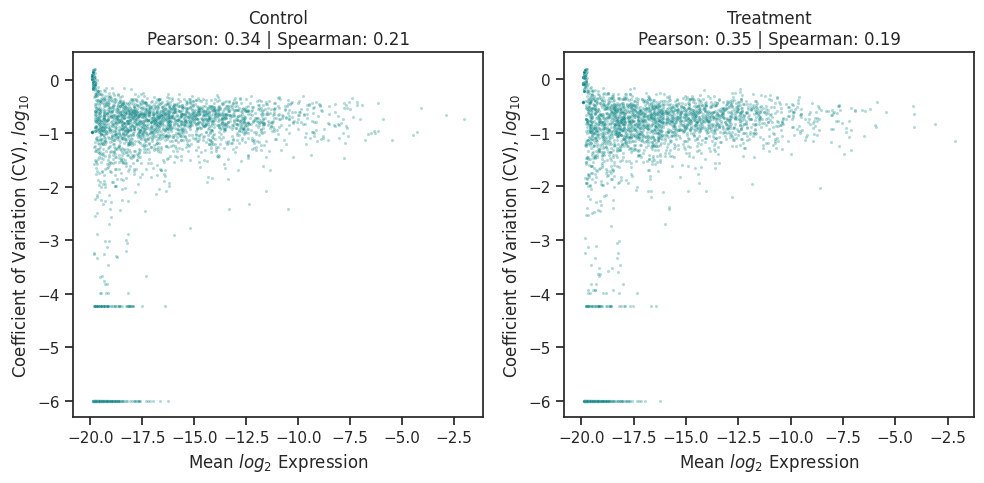

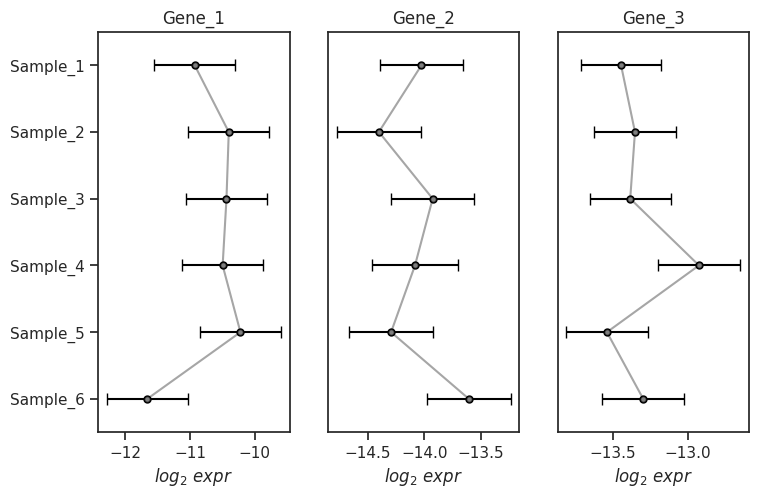

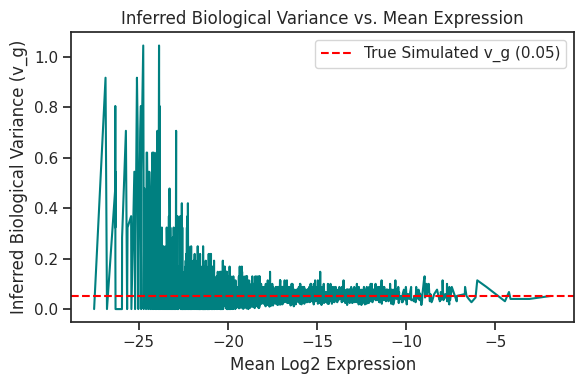

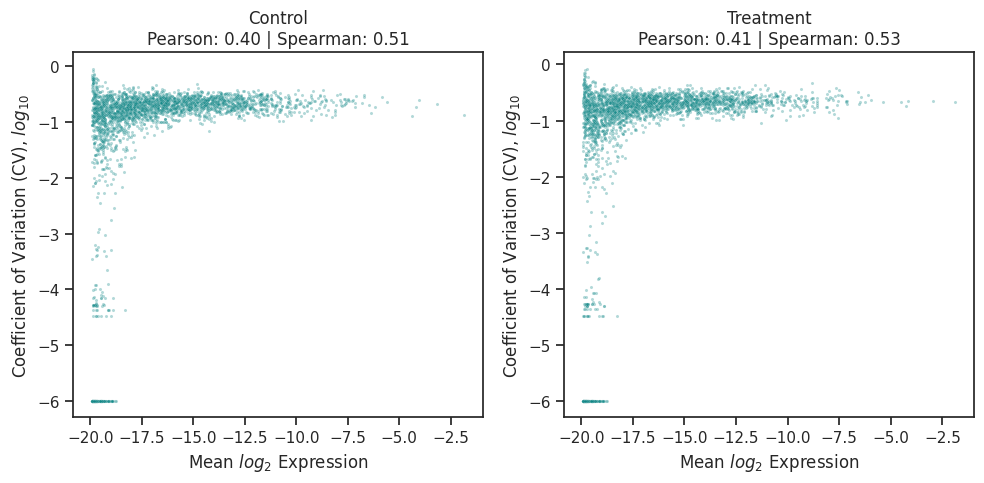

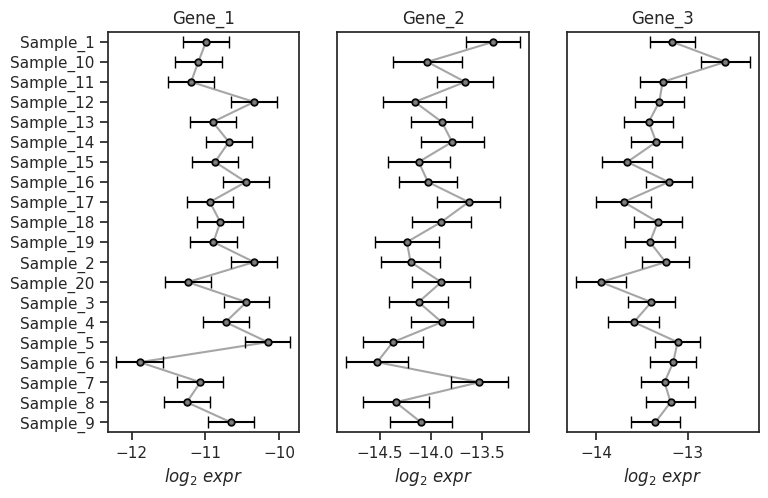

In [194]:
from zavolab_pyutils.visualization import plot_variance_vs_expression, plot_mean_vs_cv, plot_sanity_gene_expression_with_ci

replicate_options = ['3repl','10repl']
metadata_dfs = [metadata_3repl_df,metadata_10repl_df]
input_counts_dfs = [pln_counts_3repl_df,pln_counts_10repl_df]
for k,replicate_option in enumerate(replicate_options):
    Orig_sanity_norm_counts_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/log_transcription_quotients_vmax.txt',delimiter="\t",index_col=0,header=0,)
    Orig_sanity_means_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/mu_vmax.txt',delimiter="\t",index_col=None,header=None)
    Orig_sanity_means_df.index = Orig_sanity_norm_counts_df.index
    Orig_sanity_vg_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/variance_vmax.txt',delimiter="\t",index_col=None,header=None)
    Orig_sanity_vg_df.columns = ['inferred_v_g']
    Orig_sanity_vg_df.index = Orig_sanity_norm_counts_df.index

    Orig_sanity_errors_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/ltq_error_bars_vmax.txt',delimiter="\t",index_col=0,header=0,)
    log2Scale_Orig_sanity_errors_df = np.log2(np.exp(Orig_sanity_errors_df))
    
    log2Scale_Orig_sanity_means_df = np.log2(np.exp(Orig_sanity_means_df))

    genes_with_unexpectedly_high_Vg = Orig_sanity_vg_df.loc[Orig_sanity_vg_df['inferred_v_g']>50].index
    input_counts_df = input_counts_dfs[k].copy()
    if len(genes_with_unexpectedly_high_Vg)>0:
        print('input counts for genes with unexpectedly high biological var, '+replicate_option+':\n')
        print(input_counts_df.loc[genes_with_unexpectedly_high_Vg].head(3))
        
    plot_variance_vs_expression(
        log2Scale_Orig_sanity_means_df, Orig_sanity_vg_df, 
        savefig_path='./tests/plots/variance_vs_expr.Orig_Sanity.'+replicate_option+'.png',
        true_vg=0.05 # This is to compare with True value specified during simulation above
    )
    natScale_Orig_sanity_norm_counts_df = np.exp(Orig_sanity_norm_counts_df)
    Log2Scale_Orig_sanity_norm_counts_df = np.log2(natScale_Orig_sanity_norm_counts_df)
    
    Orig_sanity_plot_data = plot_mean_vs_cv(
    natScale_Orig_sanity_norm_counts_df, metadata_dfs[k], 
    savefig_path='./tests/plots/cv_plot.Orig_Sanity.'+replicate_option+'.png')

    sel_data = Orig_sanity_plot_data.loc[Orig_sanity_plot_data['condition']=='Control']
    frac_very_low_CV = len(sel_data.loc[(sel_data['log10_cv']<-2)])/len(sel_data)
    print('fraction of genes with log10 CV < -2 is '+str(np.round(frac_very_low_CV,3))+', '+replicate_option+', "Control" condition')

    selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

    used_metadata_df = metadata_dfs[k].copy()
    used_metadata_df['condition'] = used_metadata_df['sample'] # in Original Sanity, there is no way to aggregate over multiple samples.
    
    plot_sanity_gene_expression_with_ci(
    sample_norm_df=Log2Scale_Orig_sanity_norm_counts_df, 
    means_df=Log2Scale_Orig_sanity_norm_counts_df, 
    errors_df=log2Scale_Orig_sanity_errors_df, 
    metadata_df=used_metadata_df, 
    selected_genes=selected_genes, 
    adjust_multiple_comparisons=True,
    
    savefig_path='./tests/plots/sanity_expression_ci.Orig_Sanity.'+replicate_option+'.png')

In [320]:
# first, run Sanity without Empirical Bayes Shrinkage (as in the original paper)
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=nb_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=False,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2941 genes using 5 cores...
PASS 3: Finalizing Bayesian Posteriors...
Sanity normalization complete.


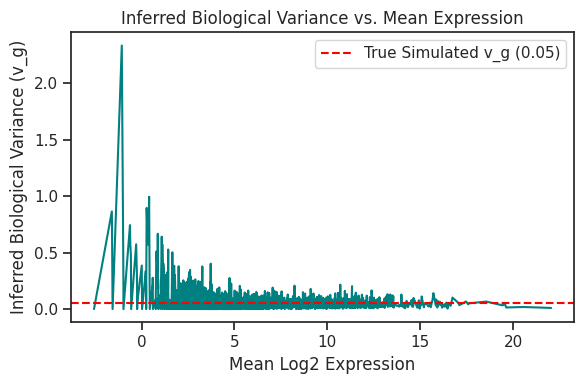

In [321]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.without_Empir_Bayes_Shrinkage.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

In [332]:
# now, run Sanity with Empirical Bayes Shrinkage that takes advantage of mean-variance relatioship across genes
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=nb_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=True,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2941 genes using 5 cores...
PASS 2: Applying Empirical Bayes Variance Shrinkage (Overdispersion-Only Fit)...
PASS 3: Finalizing Bayesian Posteriors...


/scicore/home/zavolan/mirono0000/miniforge3_Dec2024/envs/zavolab_pyutils/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Sanity normalization complete.


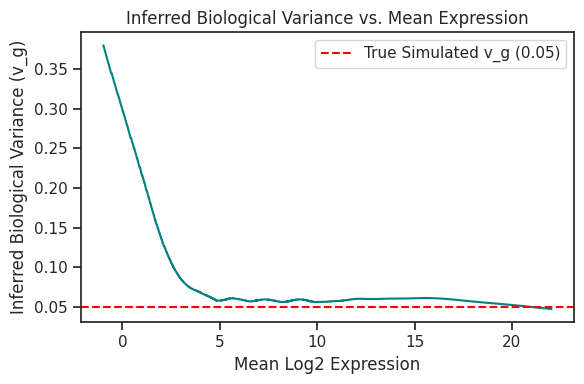

In [333]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

## Diagnostic plots for expression normalization confounders

these make more sense at larger number of replicates, like >15, because otherwise observed between-bioreplicate variance is mostly just technical noise

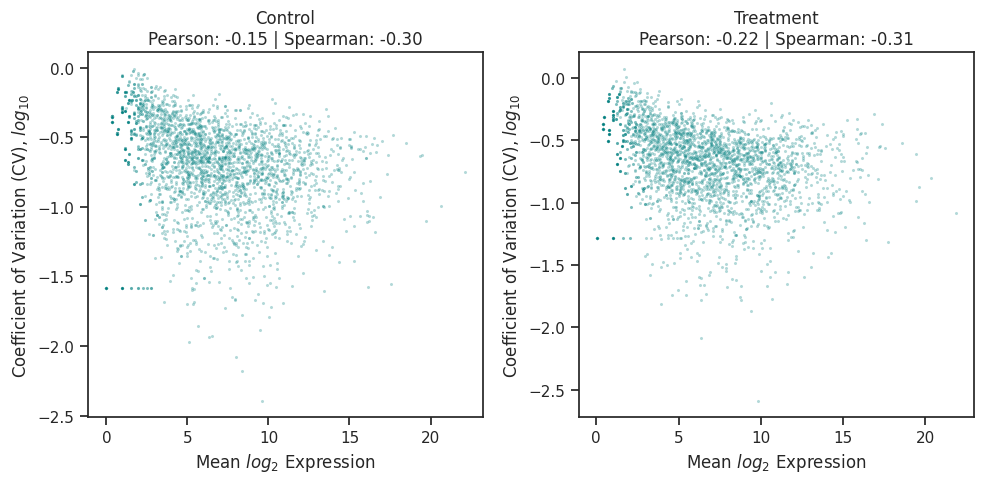

In [334]:
# 1. DESeq2 Mean vs CV (is_log2 = False because norm_counts is on raw scale)
deseq_plot_data = plot_mean_vs_cv(
    norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_deseq2.png', 
    is_log2=False
)

In [ ]:
# 2. Sanity Mean vs CV (is_log2 = True to convert log2 back to raw for CV math)
sanity_plot_data = plot_mean_vs_cv(
    sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_sanity.png', 
    is_log2=True
)

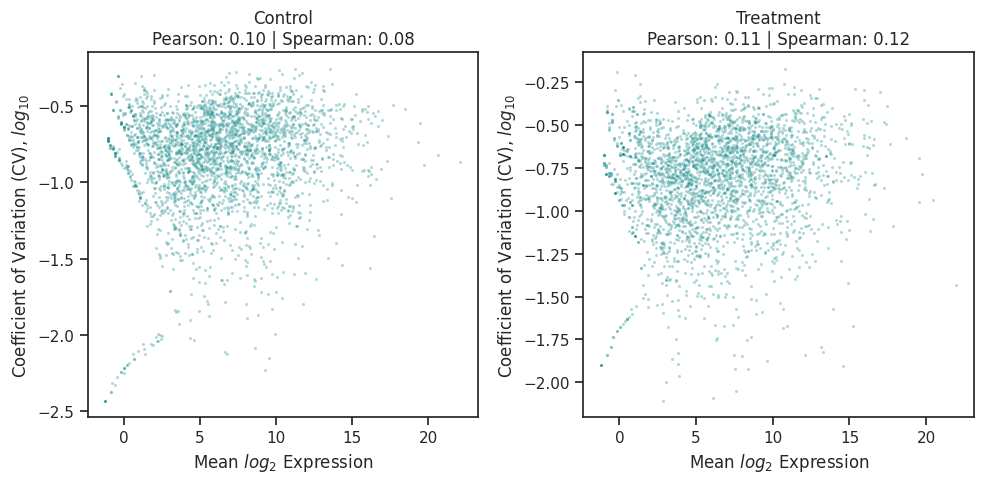

In [335]:
# 2. Sanity Mean vs CV (is_log2 = True to convert log2 back to raw for CV math)
sanity_plot_data = plot_mean_vs_cv(
    sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_sanity.png', 
    is_log2=True
)

## Differential expression testing based on Sanity's and Mean-variance QuantReg modelling (DESeq2-like) output

### Sanity

In [342]:
sanity_DE_df = test_differential_expression(
    means_df=sanity_means_df, 
    errors_df=sanity_errors_df, 
    cond_A="Treatment", 
    cond_B="Control"
)

In [378]:
# False discovery rate is:
len(sanity_DE_df.loc[sanity_DE_df['padj']<0.05])/len(sanity_DE_df)

0.013600816048962938

### mean-variance modelling with QuantReg

In [353]:
# 1. Extract exact means and standard errors using the fitted QuantReg alpha
deseq_means_df, deseq_errors_df = get_deseq2_means_and_errors(
    norm_counts_df=norm_counts_df, 
    metadata_df=metadata_df, 
    regr_model_df=regr_model_df
)

In [354]:
deseq_DE_df = test_differential_expression(
    means_df=deseq_means_df, 
    errors_df=deseq_errors_df, 
    cond_A="Treatment", 
    cond_B="Control"
)

In [355]:
# False discovery rate is:
len(deseq_DE_df.loc[deseq_DE_df['padj']<0.05])/len(deseq_DE_df)

0.0

In [377]:
deseq_DE_df['padj'].min()

np.float64(0.47520613158068)

## Plottting expression of individual genes with confidence intervals

In [371]:
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

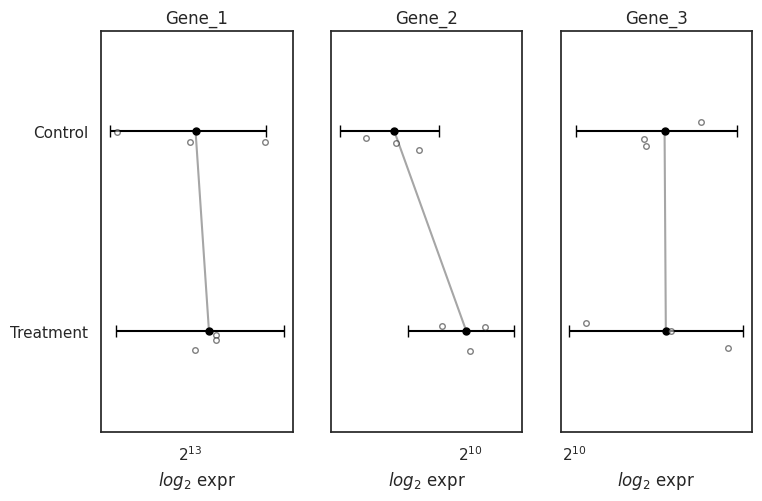

In [375]:
plot_gene_expression_with_ci(
    norm_counts_df=norm_counts_df, 
    means_df=deseq_means_df, 
    errors_df=deseq_errors_df, 
    metadata_df=metadata_df, 
    selected_genes=selected_genes, 
    savefig_path='./tests/plots/deseq_expression_ci.png',
    adjust_multiple_comparisons=True, # Optional Bonferroni adjustment
    log_scale=True,                    # Visually condenses the linear x-axis
)

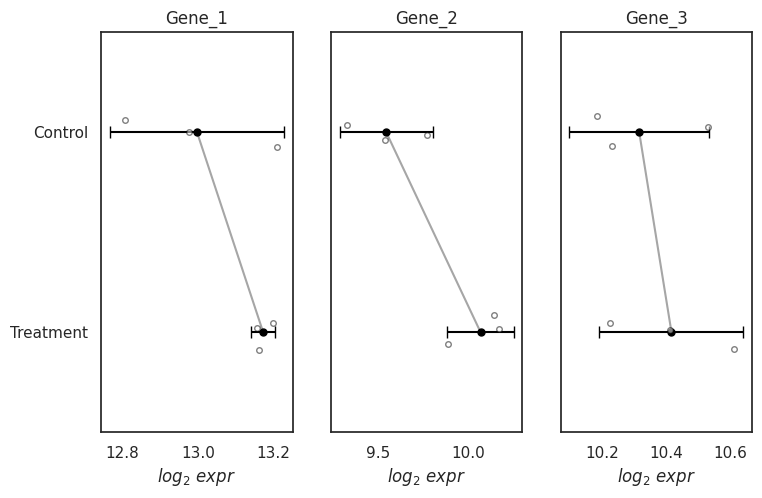

In [376]:
plot_sanity_gene_expression_with_ci(
    sample_norm_df=sanity_norm_counts_df, 
    means_df=sanity_means_df, 
    errors_df=sanity_errors_df, 
    metadata_df=metadata_df, 
    selected_genes=selected_genes, 
    adjust_multiple_comparisons=True,
    savefig_path='./tests/plots/sanity_expression_ci.png'
)